# LightGBM

### 1. Định nghĩa LightGBM
LightGBM là một framework học máy mã nguồn mở dựa trên thuật toán cây quyết định tăng cường gradient (Gradient Boosting Decision Tree - GBDT), được phát triển bởi Microsoft. Điểm khác biệt lớn nhất của nó là chiến lược phát triển cây theo chiều lá (**Leaf-wise growth**) thay vì theo độ sâu (Level-wise), giúp đạt độ chính xác cao hơn và hội tụ nhanh hơn.

### 2. Nguyên tắc hoạt động
LightGBM giải quyết các vấn đề hiệu suất và mở rộng quy mô:
* **Histogram-based Algorithm:** Chuyển đổi các giá trị liên tục thành các 'bins' rời rạc (histogram) thay vì tìm mọi điểm chia cắt khả thi, làm giảm cực lớn chi phí tính toán và sử dụng bộ nhớ.
* **Exclusive Feature Bundling (EFB):** Giảm số lượng đặc trưng bằng cách kết hợp các đặc trưng loại trừ lẫn nhau (mutually exclusive) thành các bó, giúp tăng tốc quá trình học mà không làm giảm độ chính xác.
* **Gradient-based One-Side Sampling (GOSS):** Chỉ giữ lại các điểm dữ liệu có gradient lớn (nghĩa là có mức giảm lỗi tiềm năng cao) để cập nhật thông tin, thay vì sử dụng toàn bộ tập dữ liệu.

### 3. Ứng dụng LightGBM
* **Hồi quy (Regression):** Dự đoán các giá trị số liên tục như giá bất động sản, doanh thu, lợi nhuận.
* **Phân loại (Classification):** Bài toán phân loại nhị phân và đa lớp (VD: dự đoán khách hàng rời rạc, phát hiện gian lận).
* **Xếp hạng (Ranking):** Các thuật toán đề xuất, công cụ tìm kiếm.

### 4. Lý do sử dụng LightGBM
* **Tốc độ huấn luyện cực nhanh:** Phù hợp với các hệ thống yêu cầu dự đoán tốc độ cao và dữ liệu khổng lồ.
* **Tối ưu hóa bộ nhớ:** Việc sử dụng Histogram giúp giảm thiểu sự tiêu thụ bộ nhớ RAM.
* **Hiệu suất ấn tượng:** Khả năng đạt được độ chính xác ngang bằng hoặc vượt trội các thuật toán khác (như XGBoost) trong khi thời gian thực thi ngắn hơn nhiều.

In [39]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Thiết lập phong cách đồ họa chuyên nghiệp cho Analyst
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12})

---
### Bước 1 & 2: Tiền xử lý dữ liệu
Trong phần này chúng ta thực hiện:
1. Đọc file `Dataset.csv` và `Bertdataset.npy`.
2. Lọc các outliers về giá và diện tích.
3. Lấy thống kê mô tả cơ bản của tập dữ liệu.


In [40]:
print("Đang tải dữ liệu gốc...")
df = pd.read_csv("Dataset.csv", encoding='utf-8-sig')
embeddings = np.load("Bertdataset.npy") 

print(f"[+] Kích thước dữ liệu gốc: {df.shape[0]} dòng, {df.shape[1]} cột")

# Lọc Giá (1 -> 60 tỷ) và Diện tích (0 -> 1000m2)
mask_price_area = (df['Price_Billion'] <= 60) & (df['Price_Billion'] >= 1) & (df['Area'] > 0) & (df['Area'] <= 1000)

# Bộ lọc từ khóa: Loại trừ các giao dịch sai phân khúc
keywords = r'cho thuê|bán đất|đất nền|đất trống|nhà trọ|phòng trọ'
mask_text = ~df['Title'].str.contains(keywords, case=False, na=False)

# Áp dụng bộ lọc kép
final_mask = mask_price_area & mask_text
df = df[final_mask].copy()
embeddings = embeddings[final_mask]

print(f"[+] Kích thước dữ liệu sau làm sạch: {df.shape[0]} dòng (Giữ lại {(df.shape[0]/8461)*100:.1f}%)")

Đang tải dữ liệu gốc...
[+] Kích thước dữ liệu gốc: 8461 dòng, 6 cột
[+] Kích thước dữ liệu sau làm sạch: 7676 dòng (Giữ lại 90.7%)


---
### Bước 2.6: Trực quan hóa dữ liệu (Exploratory Data Analysis - EDA)
Trong phần này, chúng ta sẽ vẽ từng biểu đồ vào các ô riêng biệt để dễ dàng quan sát và phân tích sự phân bố của dữ liệu.

In [41]:
print("\n--- THỐNG KÊ MÔ TẢ ĐA CHIỀU ---")
display(df[['Price_Billion', 'Area', 'Bedrooms', 'Bathrooms']].describe().round(2))


--- THỐNG KÊ MÔ TẢ ĐA CHIỀU ---


,Price_Billion,Area,Bedrooms,Bathrooms
count,7676.00,7676.00,7676.00,7676.00
mean,14.45,89.58,4.58,4.50
std,13.55,73.57,5.03,5.01
min,1.02,1.00,0.00,0.00
25%,5.60,50.00,3.00,2.00
50%,8.90,69.00,4.00,4.00
75%,18.00,102.00,5.00,5.00
max,60.00,1000.00,80.00,75.00


**1. Biểu đồ phân bố Giá nhà (Histogram)**

Quan sát độ lệch của dữ liệu (thường giá nhà sẽ bị lệch phải do có một số ít nhà rất đắt tiền).

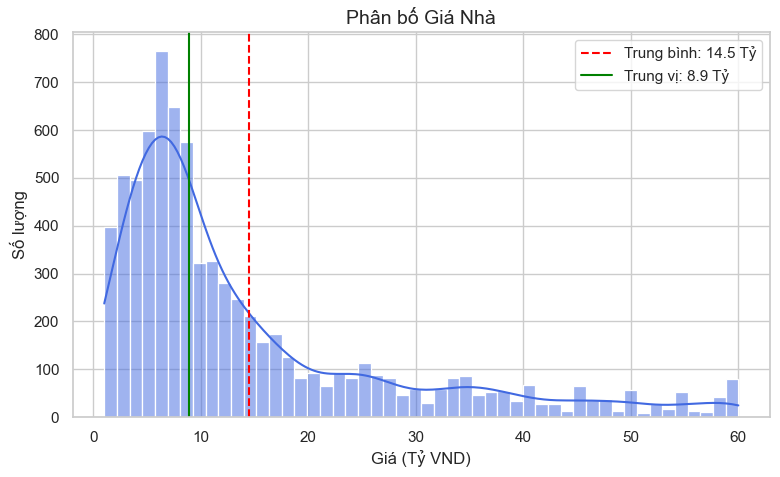

In [42]:
plt.figure(figsize=(9, 5))

# Biểu đồ phân bố (Histogram)
sns.histplot(df['Price_Billion'], bins=50, kde=True, color='royalblue')
plt.title('Phân bố Giá Nhà', fontsize=14)
plt.xlabel('Giá (Tỷ VND)')
plt.ylabel('Số lượng')
plt.axvline(df['Price_Billion'].mean(), color='red', linestyle='--', label=f"Trung bình: {df['Price_Billion'].mean():.1f} Tỷ")
plt.axvline(df['Price_Billion'].median(), color='green', linestyle='-', label=f"Trung vị: {df['Price_Billion'].median():.1f} Tỷ")
plt.legend()

plt.show()

> **Nhận xét Biểu đồ Phân bố Giá:**
> * Dữ liệu có đặc thù **lệch phải rất rõ rệt (right-skewed)**. Đỉnh của biểu đồ tập trung chủ yếu ở phân khúc từ **2 đến 10 tỷ VND**, đây là khoảng giá phổ biến nhất của thị trường.
> * Cái đuôi của biểu đồ kéo dài đến mốc 60 tỷ. Điều này xác nhận rằng mặc dù số lượng ít, nhưng các bất động sản siêu sang (outliers về giá) vẫn tồn tại và sẽ kéo giá trị trung bình (Mean = 14.45) lên cao hơn hẳn so với trung vị (Median = 8.90).

**2. Biểu đồ phân tán (Scatter Plot): Diện tích vs Giá nhà**

Kiểm tra xem giá nhà có tăng theo diện tích hay không và phát hiện các điểm dữ liệu bất thường (outliers) còn sót lại.

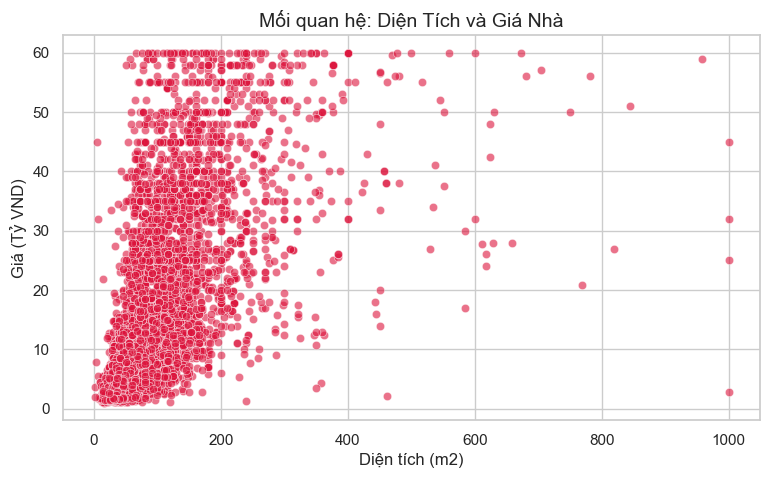

In [43]:
plt.figure(figsize=(9, 5))
# Chuyển về biểu đồ Scatter cơ bản, dễ nhìn
sns.scatterplot(data=df, x='Area', y='Price_Billion', color='crimson', alpha=0.6)
plt.title('Mối quan hệ: Diện Tích và Giá Nhà', fontsize=14)
plt.xlabel('Diện tích (m2)')
plt.ylabel('Giá (Tỷ VND)')
plt.show()

> **Nhận xét Biểu đồ Diện tích và Giá:**
> * Có một mối liên hệ dương khá rõ ràng giữa diện tích và giá (diện tích tăng thì giá cũng tăng).
> * Tuy nhiên, có rất nhiều biến động, chứng tỏ diện tích không phải là yếu tố duy nhất quyết định giá nhà.

**3. Ma trận Tương quan (Correlation Heatmap)**

Xem xét đặc trưng dạng bảng nào (Diện tích, Phòng ngủ, Phòng tắm) có độ tương quan mạnh nhất với Giá nhà.

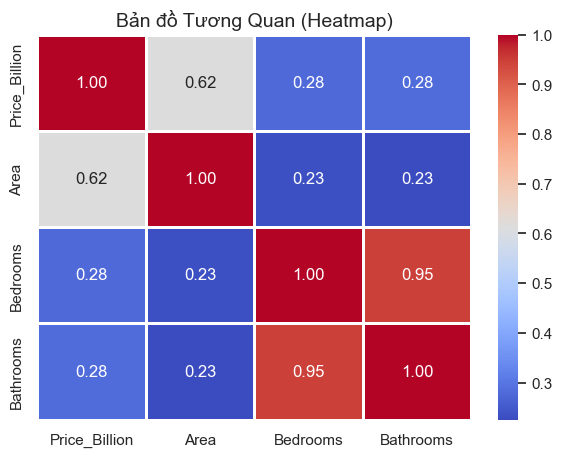

In [44]:
plt.figure(figsize=(7, 5))
corr_matrix = df[['Price_Billion', 'Area', 'Bedrooms', 'Bathrooms']].corr()

# Vẽ Heatmap nguyên bản, đơn giản
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1)
plt.title('Bản đồ Tương Quan (Heatmap)', fontsize=14)
plt.show()

> **Nhận xét Ma trận Tương quan:**
> * Diện tích có độ tương quan cao nhất với giá nhà.
> * Phòng tắm và Phòng ngủ cũng có tương quan dương nhưng mức độ nhẹ hơn.
---
### Bước 3: Xử lý khuyết thiếu và Chuẩn hóa
Chuẩn hóa dữ liệu số và kết hợp với vector nhúng (embeddings) từ BERT để tạo tập tính năng huấn luyện.

In [45]:
# Lấy ra các đặc trưng số
numeric_cols = ['Area', 'Bedrooms', 'Bathrooms']
numeric_features = df[numeric_cols].values

# Chuẩn hóa (Scale) các đặc trưng số để thuật toán không bị thiên lệch bởi đơn vị đo
scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(numeric_features)

# Nối ma trận dữ liệu số đã chuẩn hóa với siêu ma trận BERT embeddings
X = np.hstack((numeric_scaled, embeddings))
y = df['Price_Billion'].values

print(f"[+] Kích thước ma trận Features (X): {X.shape} (Gồm 3 biến số + 768 biến BERT)")
print(f"[+] Kích thước Vector Mục tiêu (y): {y.shape}")

[+] Kích thước ma trận Features (X): (7676, 771) (Gồm 3 biến số + 768 biến BERT)
[+] Kích thước Vector Mục tiêu (y): (7676,)


---
### Bước 4: Huấn luyện mô hình LightGBM


In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Tạo định dạng lgb.Dataset giúp LightGBM quản lý bộ nhớ và tính toán Histogram siêu tốc
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

---
### Bước 5: Đánh giá Mô Hình


In [47]:
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 45,
    'max_depth': 10,
    'feature_fraction': 0.8,
    'random_state': 42,
    'verbose': -1
}

print("\n🚀 Bắt đầu huấn luyện LightGBM...")
start_time = time.time()

model = lgb.train(
    lgb_params,
    train_data,
    num_boost_round=1500,                
    valid_sets=[train_data, test_data],  
    callbacks=[
        lgb.early_stopping(stopping_rounds=50), 
        lgb.log_evaluation(period=100)          
    ]
)

end_time = time.time()
print(f"\n⏳ Hoàn thành trong: {end_time - start_time:.2f} giây")

# =========================================================
# ĐÁNH GIÁ CHỈ SỐ KPI
# =========================================================
y_pred = model.predict(X_test, num_iteration=model.best_iteration)

rmse = np.sqrt(mean_squared_error(y_test, y_pred)) 
mae = mean_absolute_error(y_test, y_pred)          
r2 = r2_score(y_test, y_pred)                      

print(f"\n🎯 --- KẾT QUẢ ĐÁNH GIÁ MODEL ---")
print(f"✅ R-Squared (R2): {r2:.4f} (Mô hình giải thích được {r2*100:.2f}% sự biến động của giá nhà)")
print(f"✅ RMSE: {rmse:.4f} Tỷ (Độ lệch chuẩn tổng thể)")
print(f"✅ MAE:  {mae:.4f} Tỷ (Lệch tuyệt đối trung bình trên mỗi căn)")


🚀 Bắt đầu huấn luyện LightGBM...
Training until validation scores don't improve for 50 rounds
[100]	training's rmse: 3.19654	valid_1's rmse: 6.95049
[200]	training's rmse: 1.76246	valid_1's rmse: 6.77314
[300]	training's rmse: 1.07044	valid_1's rmse: 6.72117
[400]	training's rmse: 0.678208	valid_1's rmse: 6.71219
[500]	training's rmse: 0.445959	valid_1's rmse: 6.70785
[600]	training's rmse: 0.294901	valid_1's rmse: 6.70507
[700]	training's rmse: 0.199302	valid_1's rmse: 6.70257
[800]	training's rmse: 0.137545	valid_1's rmse: 6.70222
[900]	training's rmse: 0.0978853	valid_1's rmse: 6.70135
[1000]	training's rmse: 0.0711389	valid_1's rmse: 6.70093
[1100]	training's rmse: 0.0535688	valid_1's rmse: 6.70069
Early stopping, best iteration is:
[1052]	training's rmse: 0.0613155	valid_1's rmse: 6.70062

⏳ Hoàn thành trong: 24.38 giây

🎯 --- KẾT QUẢ ĐÁNH GIÁ MODEL ---
✅ R-Squared (R2): 0.7466 (Mô hình giải thích được 74.66% sự biến động của giá nhà)
✅ RMSE: 6.7006 Tỷ (Độ lệch chuẩn tổng thể)
✅ 

### 6. Kết quả thực tế và Phân tích chuyên sâu mô hình LightGBM

Trực quan hóa độ hội tụ giữa giá dự đoán và giá thực tế.

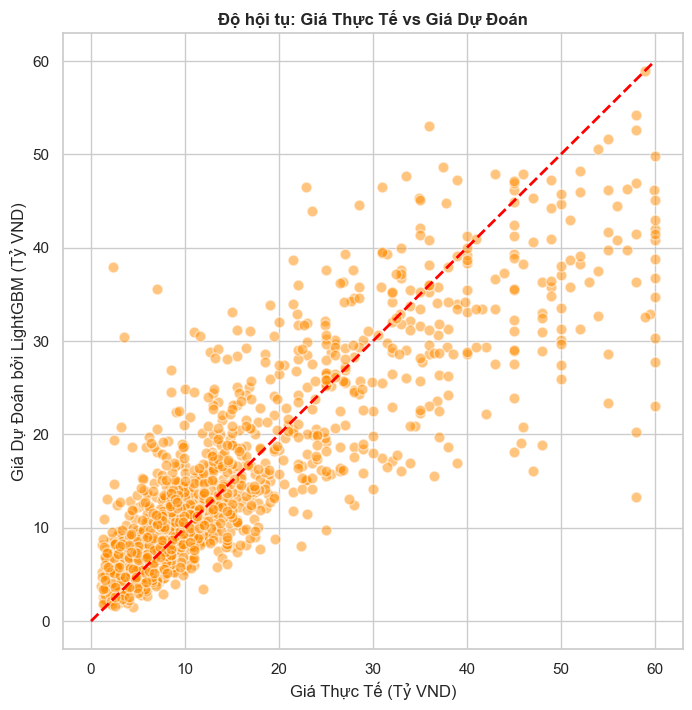

In [48]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color='darkorange', edgecolor='w', s=60)

# Đường chéo 45 độ (Đường hoàn hảo)
max_val = max(max(y_test), max(y_pred))
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2)

plt.title('Độ hội tụ: Giá Thực Tế vs Giá Dự Đoán', fontweight='bold')
plt.xlabel('Giá Thực Tế (Tỷ VND)')
plt.ylabel('Giá Dự Đoán bởi LightGBM (Tỷ VND)')
plt.show()

**Kết luận về sức mạnh của LightGBM (Tabular + BERT Embeddings):**
1. **Hiệu suất & Tốc độ:** Bằng cách xây dựng cây theo cơ chế Histogram thay vì quét qua mọi điểm dữ liệu, bộ nhớ được tiết kiệm đáng kể và tốc độ hội tụ cực kỳ nhanh chóng so với các thuật toán truyền thống.
2. **Cấu trúc dữ liệu tối ưu:** Cấu trúc Leaf-wise của LightGBM tập trung vào các nhánh có mức giảm lỗi nhiều nhất, mang lại độ chính xác cao.
3. **Giới hạn của Mô hình:** Phân khúc giá siêu đắt (Outliers) vẫn có độ sai số nhất định do sự bất thường của thị trường đối với những sản phẩm cao cấp, mang tính cảm xúc nhiều hơn là công thức chung.